1. Calculate the modes for t=0.5
2. Assing every molecule to a similar mode (t=0.5, ... t=0.9)
3. Plot the histogram with number of molecules
4. PLot the plot with entropy

In [41]:
from typing import Tuple, List, Any
from rdkit.DataStructs import BulkTanimotoSimilarity
from pathlib import Path
import pickle
from rdkit.Chem import MolFromSmiles, AllChem
import matplotlib.pyplot as plt
import numpy as np

from notebooks.utils.training_results import TrainingResults
from tqdm.auto import tqdm

model_names = ['rgfn_is_decomposable', 'rgfn_cost_biasing', 'rgfn_expl_bias']
template_name = 'synflow_64'
n_seeds = 1
similarity_threshold = 0.3
considered_molecules_threshold = 7.0
cache_path = Path(f'cache/exploitation_results_dict_{similarity_threshold}_{considered_molecules_threshold}.pkl')

from collections import defaultdict


def _get_fp(smiles: str, fp_type: str):
    if 'morgan' in fp_type:
        radius = int(fp_type[-1])
        return AllChem.GetMorganFingerprintAsBitVect(
            MolFromSmiles(smiles), radius=radius, nBits=2048, useFeatures=False, useChirality=False
        )
    else:
        raise ValueError(f"Unknown fp_type: {fp_type}")


def get_modes_smiles_and_fps(result: TrainingResults, similarity_threshold: float, reward_threshold: float) -> Tuple[
    List[str], List[Any]]:
    modes_smiles = []
    modes_fps = []
    sorted_indices = np.argsort(result.rewards)[::-1]
    for i in tqdm(sorted_indices):
        if result.rewards[i] >= reward_threshold:
            smiles, fps = result.molecules[i], result.all_fps[i]
            similarities = BulkTanimotoSimilarity(fps, modes_fps)
            if len(similarities) == 0 or max(similarities) <= similarity_threshold:
                modes_smiles.append(smiles)
                modes_fps.append(fps)
    
    print(f'Number of modes: {len(modes_smiles)} for {result.model_name}')
    return modes_smiles, modes_fps


results_dict = defaultdict(list)
for model_name in tqdm(model_names):
    results_list = []
    for seed in range(n_seeds):
        result = TrainingResults(
            model_name=model_name,
            templates_name=template_name,
            seed=seed,
            task_name='seh',
            threshold=8.0,
            results_dir=Path('../results'),
        )
        result.load_heavy_stuff()
        result.all_fps = []
        for smiles, reward in tqdm(zip(result.molecules, result.rewards), total=len(result.molecules)):
            if reward >= considered_molecules_threshold:
                result.all_fps.append(_get_fp(smiles, 'morgan_3'))
            else:
                result.all_fps.append(None)
        modes_smiles, modes_fps = get_modes_smiles_and_fps(result, similarity_threshold=similarity_threshold,
                                                           reward_threshold=8.0)
        result.modes_smiles = modes_smiles
        result.modes_fps = modes_fps
        results_list.append(result)
    results_dict[model_name] = results_list

pickle.dump(results_dict, open(cache_path, 'wb'))
results_dict = pickle.load(open(cache_path, 'rb'))

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/320064 [00:00<?, ?it/s]

  0%|          | 0/320064 [00:00<?, ?it/s]

Number of modes: 845 for rgfn_is_decomposable


  0%|          | 0/320064 [00:00<?, ?it/s]

  0%|          | 0/320064 [00:00<?, ?it/s]

Number of modes: 663 for rgfn_cost_biasing


  0%|          | 0/320064 [00:00<?, ?it/s]

  0%|          | 0/320064 [00:00<?, ?it/s]

Number of modes: 949 for rgfn_expl_bias


In [53]:
from typing import Dict

similarity_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


def get_mode_count_dict(result: TrainingResults, modes_smiles: List[str], modes_fps: List[Any], similarity_thresholds: List[float], reward_threshold: float) -> Dict[
    float, Dict[str, int]]:
    mode_count_dict = {similarity_threshold: {smiles: 0 for smiles in modes_smiles} for similarity_threshold in
                       similarity_thresholds}
    for smiles, fps, reward in tqdm(zip(result.molecules, result.all_fps, result.rewards), total=len(result.molecules)):
        if reward >= reward_threshold:
            similarities = BulkTanimotoSimilarity(fps, modes_fps)
            for similarity, mode_smiles in zip(similarities, modes_smiles):
                for similarity_threshold in similarity_thresholds:
                    if similarity >= similarity_threshold:
                        mode_count_dict[similarity_threshold][mode_smiles] += 1

    return mode_count_dict


for model_name, results_list in tqdm(results_dict.items(), total=len(results_dict)):
    for result in results_list:
        result: TrainingResults
        result.modes_count_dict = {}
        for other_model_name, other_results_list in tqdm(results_dict.items(), total=len(results_dict)):
            assert len(other_results_list) == 1
            other_results = other_results_list[0]
            modes_count_dict = get_mode_count_dict(result, 
                                                   modes_smiles=other_results.modes_smiles,
                                                   modes_fps=other_results.modes_fps,
                                                   similarity_thresholds=similarity_thresholds,
                                                   reward_threshold=considered_molecules_threshold)
            result.modes_count_dict[other_model_name] = modes_count_dict

pickle.dump(results_dict, open(cache_path, 'wb'))
results_dict = pickle.load(open(cache_path, 'rb'))

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/320064 [00:00<?, ?it/s]

  0%|          | 0/320064 [00:00<?, ?it/s]

  0%|          | 0/320064 [00:00<?, ?it/s]

...

  0%|          | 0/320064 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/320064 [00:00<?, ?it/s]

  0%|          | 0/320064 [00:00<?, ?it/s]

  0%|          | 0/320064 [00:00<?, ?it/s]

rgfn_is_decomposable rgfn_is_decomposable 0.5 6.567175758222692
rgfn_cost_biasing rgfn_is_decomposable 0.5 3.151755851082876
rgfn_expl_bias rgfn_is_decomposable 0.5 4.043247783813802
rgfn_is_decomposable rgfn_cost_biasing 0.5 3.4218797006657398
rgfn_cost_biasing rgfn_cost_biasing 0.5 4.999945143910482
rgfn_expl_bias rgfn_cost_biasing 0.5 3.9593582557341813
rgfn_is_decomposable rgfn_expl_bias 0.5 3.1620126917538784
rgfn_cost_biasing rgfn_expl_bias 0.5 1.5545804005376724
rgfn_expl_bias rgfn_expl_bias 0.5 5.144748924618152


/var/folders/5d/02_f0b1n3s9dx9kzhkqmt2cw0000gn/T/ipykernel_78092/2668354897.py:9: RuntimeWarning: divide by zero encountered in log
  entropy = -np.nansum(probs * np.log(probs))
/var/folders/5d/02_f0b1n3s9dx9kzhkqmt2cw0000gn/T/ipykernel_78092/2668354897.py:9: RuntimeWarning: invalid value encountered in multiply
  entropy = -np.nansum(probs * np.log(probs))


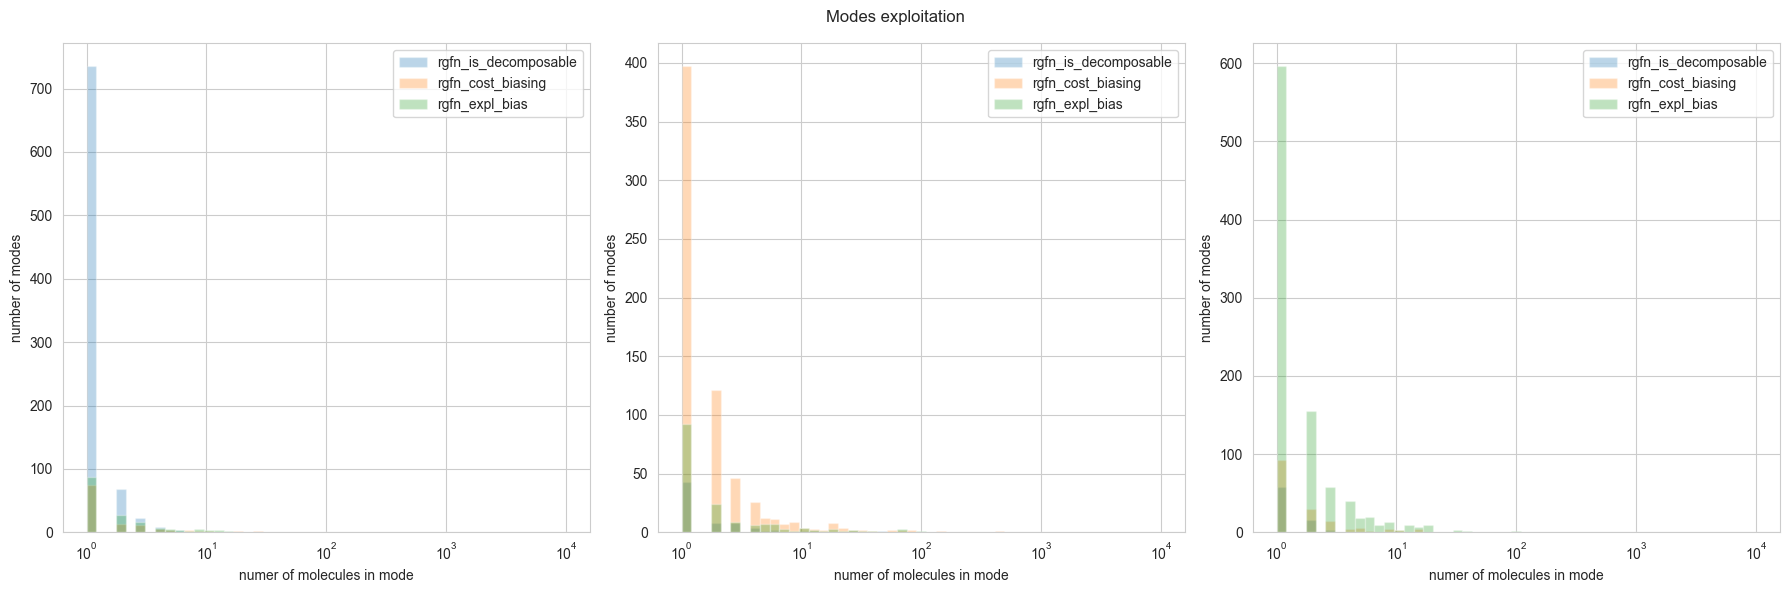

In [58]:
import matplotlib.pyplot as plt


def plot_distribution(result_list: List[TrainingResults], similarity_threshold: float, other_model_name: str):
    assert len(result_list) == 1
    name = result_list[0].model_name
    all_values_flat = np.array(list(result_list[0].modes_count_dict[other_model_name][similarity_threshold].values()))
    probs = all_values_flat / all_values_flat.sum()
    entropy = -np.nansum(probs * np.log(probs))
    print(name, other_model_name, similarity_threshold, entropy)
    plt.hist(all_values_flat, label=name, alpha=0.3, bins=np.logspace(np.log10(1.0), np.log10(10000.0)))


# plt.show()
similarity_threshold = 0.5
plt.figure(figsize=(6 * len(model_names), 6))
grid = (1, len(model_names))
plt.suptitle(f'Modes exploitation')
for i, other_model_name in enumerate(model_names, 1):
    plt.subplot(*grid, i)
    for results_list in results_dict.values():
        plot_distribution(results_list, similarity_threshold=similarity_threshold, other_model_name=other_model_name)

    plt.xlabel('numer of molecules in mode')
    plt.ylabel('number of modes')
    plt.legend()
    plt.xscale('log')
plt.tight_layout()
plt.savefig(f'outputs/molecules_in_modes_histogram_{similarity_threshold}.pdf')
plt.show()

In [52]:
results_dict['rgfn_is_decomposable'][0].modes_count_dict == results_dict['rgfn_cost_biasing'][0].modes_count_dict

True

In [94]:
from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol, MakeScaffoldGeneric
from rdkit.Chem import MolToSmiles

def _get_scaffold(smiles: str, generic: bool = False):
    mol = MolFromSmiles(smiles)
    scaffold_mol = GetScaffoldForMol(mol)
    if generic:
        try:
            scaffold_mol = MakeScaffoldGeneric(scaffold_mol)
        except:
            return None
    return MolToSmiles(scaffold_mol)

for model_name, results_list in tqdm(results_dict.items()):
    for result in results_list:
        result: TrainingResults
        scaffolds_generic = []
        for smiles in tqdm(result.molecules):
            scaffolds_generic.append(_get_scaffold(smiles, generic=True))
        result.scaffolds_generic = scaffolds_generic

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/320064 [00:00<?, ?it/s]

[16:58:12] Explicit valence for atom # 9 C, 10, is greater than permitted
[16:58:54] Explicit valence for atom # 42 C, 10, is greater than permitted


  0%|          | 0/320064 [00:00<?, ?it/s]

[17:03:44] Explicit valence for atom # 5 C, 10, is greater than permitted
[17:04:18] Explicit valence for atom # 48 C, 10, is greater than permitted
[17:07:38] Explicit valence for atom # 45 C, 10, is greater than permitted


  0%|          | 0/320064 [00:00<?, ?it/s]

In [95]:
pickle.dump(results_dict, open(cache_path, 'wb'))

In [102]:
for model_name, results_list in tqdm(results_dict.items()):
    for result in results_list:
        result: TrainingResults
        result.scaffold_max_score = {}
        result.scaffold_count = {}
        for scaffold, reward in zip(result.scaffolds_generic, result.rewards):
            result.scaffold_max_score[scaffold] = max(result.scaffold_max_score.get(scaffold, -np.inf), reward)
            result.scaffold_count[scaffold] = result.scaffold_count.get(scaffold, 0) + 1
        for threshold in [5.0]:
            scaffolds = [scaffold for scaffold, count in result.scaffold_max_score.items() if count >= threshold]
            counts = [result.scaffold_count[scaffold] for scaffold in scaffolds]
            n_repeated = np.sum(counts) - len(counts)
            average_count = np.mean(counts)
            average_repeat = n_repeated / len(counts)
            n_scaffolds = len(scaffolds)
            print(model_name, threshold, n_scaffolds, n_repeated, average_count, average_repeat)

  0%|          | 0/3 [00:00<?, ?it/s]

rgfn_is_decomposable 5.0 290456 2013 1.006930481725287 0.006930481725287135
rgfn_cost_biasing 5.0 293769 4121 1.0140280288253696 0.014028028825369594
rgfn_expl_bias 5.0 315291 600 1.001903003891643 0.0019030038916429584


  0%|          | 0/3 [00:00<?, ?it/s]

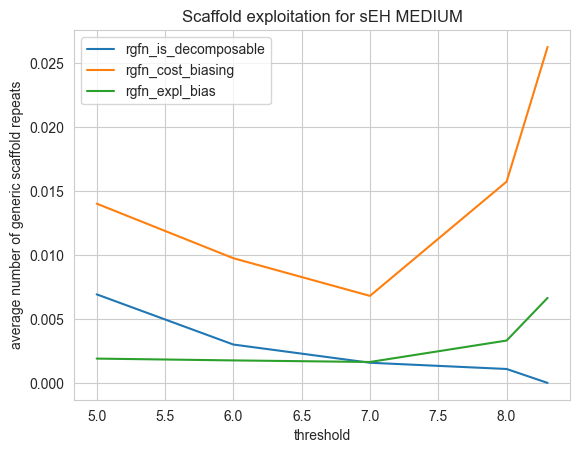

In [111]:
threshold_list = [5.0, 6.0, 7.0, 8.0, 8.3]
for model_name, results_list in tqdm(results_dict.items()):
    result = results_list[0]
    repeats_list = []
    for low in threshold_list:
        scaffolds = [scaffold for scaffold, count in result.scaffold_max_score.items() if low <= count ]
        counts = [result.scaffold_count[scaffold] for scaffold in scaffolds]
        n_repeated = np.sum(counts) - len(counts)
        average_repeat = n_repeated / len(counts)
        repeats_list.append(average_repeat)
    plt.plot(threshold_list, repeats_list, label=model_name)
plt.title('Scaffold exploitation for sEH MEDIUM')
plt.xlabel('threshold')
plt.ylabel('average number of generic scaffold repeats')
plt.legend()
plt.show()

15
rgfn_is_decomposable 2.552171949306366 3
536
rgfn_cost_biasing 5.3807595174642735 34
79
rgfn_expl_bias 4.077241790642973 8


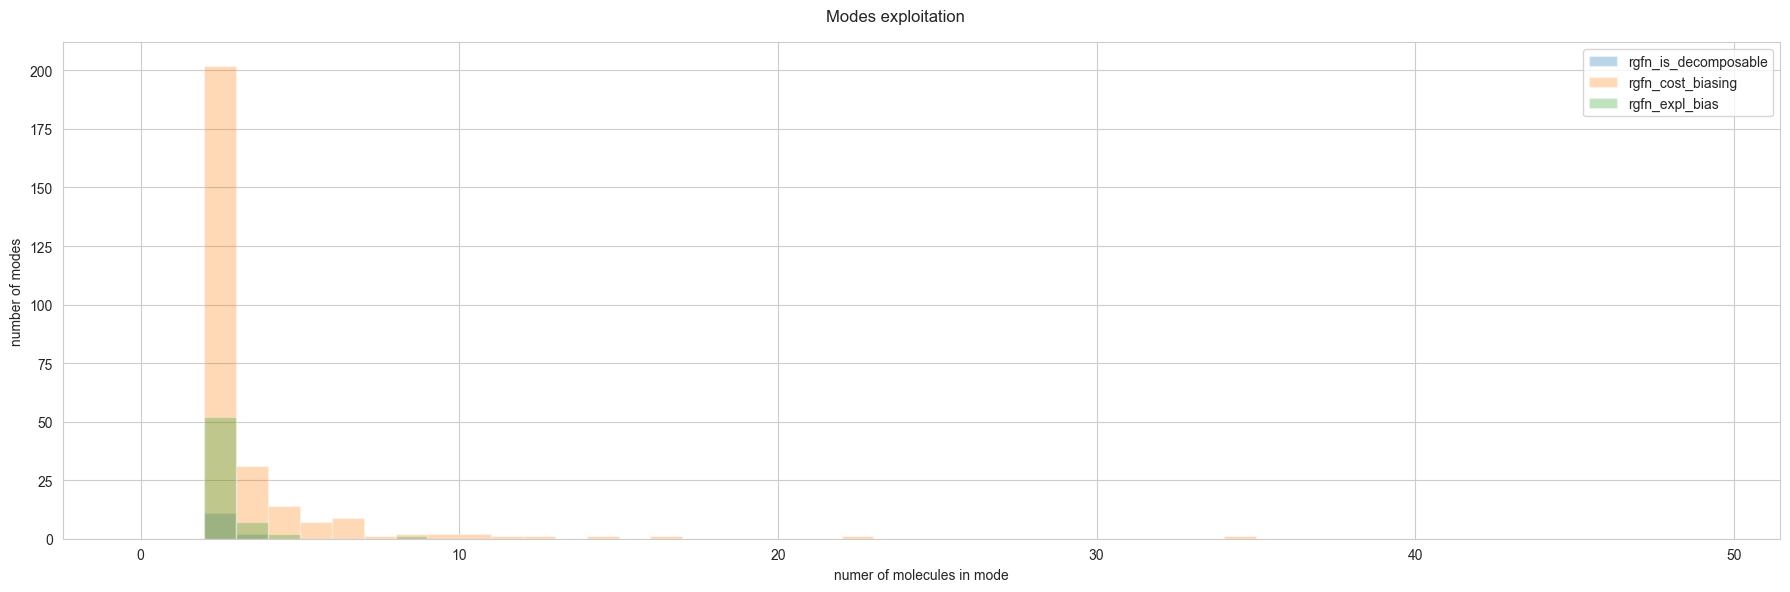

In [86]:
def plot_duplicates_histogram(result_list: List[TrainingResults]):
    assert len(result_list) == 1
    name = result_list[0].model_name
    all_values_flat = np.array([r for r in result_list[0].duplicates_dict.values() if r > 1])
    print(np.sum(all_values_flat) - len(all_values_flat))
    probs = all_values_flat / all_values_flat.sum()
    entropy = -np.nansum(probs * np.log(probs))
    print(name, entropy, max(all_values_flat))
    plt.hist(all_values_flat, label=name, alpha=0.3, bins=list(range(50)))

# plt.show()
similarity_threshold = 0.5
plt.figure(figsize=(6 * len(model_names), 6))
grid = (1, len(model_names))
plt.suptitle(f'Modes exploitation')

for results_list in results_dict.values():
    plot_duplicates_histogram(results_list)

plt.xlabel('numer of molecules in mode')
plt.ylabel('number of modes')
plt.legend()
# plt.xscale('log')
plt.tight_layout()
plt.savefig(f'outputs/molecules_in_modes_histogram_{similarity_threshold}.pdf')
plt.show()

In [ ]:
# from typing import List, Any, Tuple
# 
#     
# 
# for model_name, results_list in tqdm(results_dict.items()):
#     for result in results_list:
#         result: TrainingResults
#         result.modes_fps = [_get_fp(smiles, 'morgan_3') for smiles in result.molecules]